In [1]:
!pip install timm thop

# **Imports**

In [2]:
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

# **Device**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# **Image Preprocessing**

In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# **Load Dataset** 

In [5]:
data_path = "/kaggle/input/datasets/adithyadiwamjee/traun-dataset2/train_data"

dataset = ImageFolder(data_path, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset,[train_size,val_size])

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32)

# **Load DenseNet121**

In [6]:
model = timm.create_model("densenet121", pretrained=True)

model.reset_classifier(30)

model = model.to(device)

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

# **Linear Probe (Freeze Backbone)**

In [7]:
for param in model.parameters():
    param.requires_grad = False

for param in model.get_classifier().parameters():
    param.requires_grad = True

# **Optimizer + Loss**

In [8]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

# **Training Function**

In [9]:
def train_model(model, train_loader, val_loader, epochs=15):

    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):

        model.train()

        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct/total
        train_acc_list.append(train_acc)

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                preds = outputs.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct/total
        val_acc_list.append(val_acc)

        print(f"Epoch {epoch+1} Train:{train_acc:.3f} Val:{val_acc:.3f}")

    return train_acc_list, val_acc_list

# **Train Model**

In [10]:
train_acc, val_acc = train_model(model,train_loader,val_loader,epochs=15)

Epoch 1 Train:0.635 Val:0.816
Epoch 2 Train:0.844 Val:0.847
Epoch 3 Train:0.885 Val:0.866
Epoch 4 Train:0.912 Val:0.868
Epoch 5 Train:0.928 Val:0.873
Epoch 6 Train:0.937 Val:0.876
Epoch 7 Train:0.947 Val:0.879
Epoch 8 Train:0.957 Val:0.873
Epoch 9 Train:0.960 Val:0.876
Epoch 10 Train:0.963 Val:0.873
Epoch 11 Train:0.968 Val:0.886
Epoch 12 Train:0.971 Val:0.884
Epoch 13 Train:0.975 Val:0.882
Epoch 14 Train:0.975 Val:0.872
Epoch 15 Train:0.977 Val:0.882


# **Accuracy Plot**

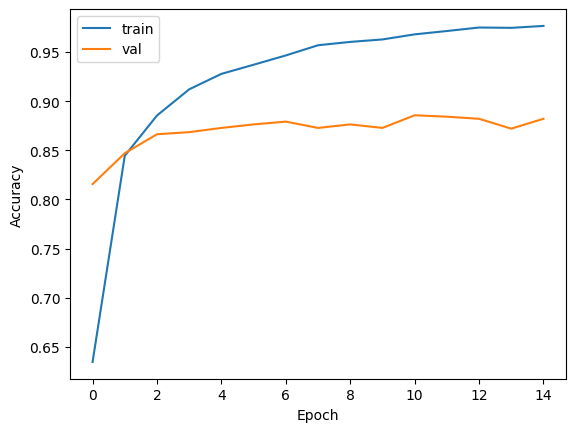

In [11]:
plt.plot(train_acc,label="train")
plt.plot(val_acc,label="val")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# **Confusion Matrix**

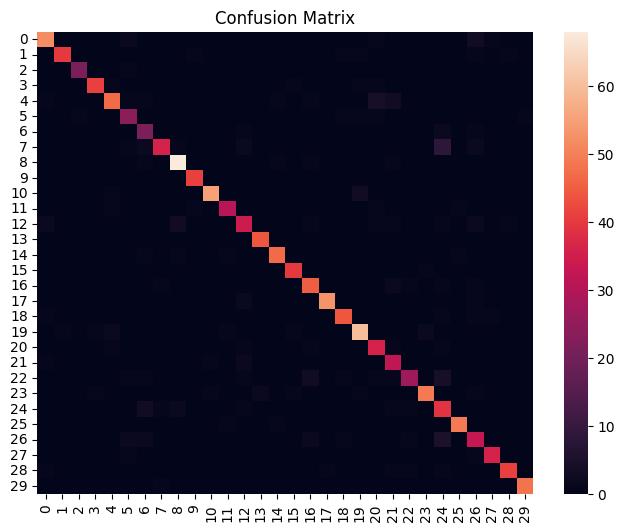

In [12]:
all_preds=[]
all_labels=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels,all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(cm)

plt.title("Confusion Matrix")

plt.show()

# **Feature Embedding (PCA)**

In [13]:
features=[]
labels_list=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images = images.to(device)

        feat = model.forward_features(images)

        feat = feat.mean(dim=(2,3))

        features.append(feat.cpu())
        labels_list.append(labels)

features = torch.cat(features)
labels_list = torch.cat(labels_list)

# **PCA Plot**

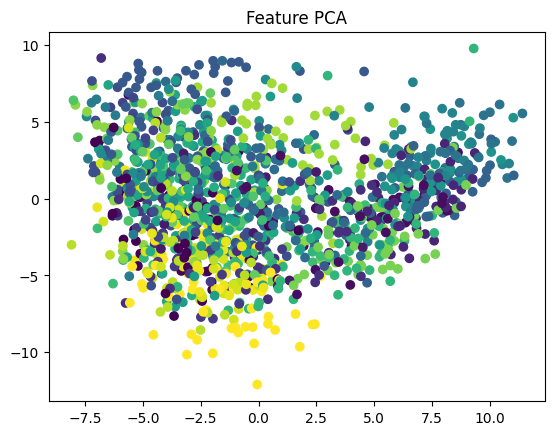

In [14]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(features)

plt.scatter(reduced[:,0],reduced[:,1],c=labels_list)

plt.title("Feature PCA")

plt.show()

# **4.2 — Fine Tuning Strategies**
Helper (count parameters)

In [15]:
def count_trainable(model):

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())

    print("Trainable %:", trainable/total)

# **Last Block Fine-Tuning (DenseNet)**

In [16]:
model = timm.create_model("densenet121", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False

# unfreeze last dense block
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.get_classifier().parameters():
    param.requires_grad = True

count_trainable(model)

train_acc_lb, val_acc_lb = train_model(model,train_loader,val_loader)

Trainable %: 0.31337916555350437
Epoch 1 Train:0.034 Val:0.031
Epoch 2 Train:0.034 Val:0.029
Epoch 3 Train:0.035 Val:0.031
Epoch 4 Train:0.034 Val:0.030
Epoch 5 Train:0.033 Val:0.032
Epoch 6 Train:0.030 Val:0.033
Epoch 7 Train:0.031 Val:0.029
Epoch 8 Train:0.033 Val:0.025
Epoch 9 Train:0.033 Val:0.027
Epoch 10 Train:0.032 Val:0.031
Epoch 11 Train:0.031 Val:0.029
Epoch 12 Train:0.029 Val:0.031
Epoch 13 Train:0.036 Val:0.031
Epoch 15 Train:0.032 Val:0.029


# **Selective 20% Unfreeze**

In [17]:
model = timm.create_model("densenet121", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False

# unfreeze last two blocks
for param in model.features.denseblock3.parameters():
    param.requires_grad = True

for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.get_classifier().parameters():
    param.requires_grad = True

count_trainable(model)

train_acc_sel, val_acc_sel = train_model(model,train_loader,val_loader)

Trainable %: 0.7196669361163679
Epoch 1 Train:0.032 Val:0.026
Epoch 2 Train:0.028 Val:0.024
Epoch 3 Train:0.028 Val:0.023
Epoch 4 Train:0.029 Val:0.025
Epoch 5 Train:0.028 Val:0.026
Epoch 6 Train:0.029 Val:0.027
Epoch 7 Train:0.030 Val:0.021
Epoch 8 Train:0.026 Val:0.029
Epoch 9 Train:0.029 Val:0.025
Epoch 10 Train:0.025 Val:0.026
Epoch 11 Train:0.028 Val:0.027
Epoch 12 Train:0.028 Val:0.024
Epoch 13 Train:0.028 Val:0.026
Epoch 14 Train:0.028 Val:0.025
Epoch 15 Train:0.027 Val:0.026


# **Full Fine Tuning**

In [18]:
model = timm.create_model("densenet121", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = True

count_trainable(model)

train_acc_full, val_acc_full = train_model(model,train_loader,val_loader)

Trainable %: 1.0
Epoch 1 Train:0.026 Val:0.029
Epoch 2 Train:0.025 Val:0.026
Epoch 3 Train:0.027 Val:0.031
Epoch 4 Train:0.028 Val:0.024
Epoch 5 Train:0.025 Val:0.028
Epoch 6 Train:0.025 Val:0.027
Epoch 7 Train:0.026 Val:0.024
Epoch 8 Train:0.026 Val:0.027
Epoch 9 Train:0.027 Val:0.026
Epoch 10 Train:0.028 Val:0.029
Epoch 11 Train:0.029 Val:0.027
Epoch 12 Train:0.027 Val:0.026
Epoch 13 Train:0.025 Val:0.026
Epoch 14 Train:0.028 Val:0.029
Epoch 15 Train:0.026 Val:0.027


# **4.3 — Few Shot Learning**
Create subsets

In [30]:
total_size = len(dataset)

size20 = int(0.2 * total_size)
size5 = int(0.05 * total_size)

dataset20,_ = random_split(dataset,[size20,total_size-size20])
dataset5,_ = random_split(dataset,[size5,total_size-size5])

loader20 = DataLoader(dataset20,batch_size=32,shuffle=True)
loader5 = DataLoader(dataset5,batch_size=32,shuffle=True)

# **Train 20%**

In [20]:
model = timm.create_model("densenet121", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

train_acc20, val_acc20 = train_model(model,loader20,val_loader)

Epoch 1 Train:0.023 Val:0.019
Epoch 2 Train:0.029 Val:0.023
Epoch 3 Train:0.026 Val:0.019
Epoch 4 Train:0.027 Val:0.021
Epoch 5 Train:0.028 Val:0.016
Epoch 6 Train:0.033 Val:0.025
Epoch 7 Train:0.031 Val:0.021
Epoch 8 Train:0.026 Val:0.022
Epoch 9 Train:0.028 Val:0.020
Epoch 10 Train:0.026 Val:0.024
Epoch 11 Train:0.028 Val:0.019
Epoch 12 Train:0.030 Val:0.024
Epoch 13 Train:0.027 Val:0.019
Epoch 14 Train:0.029 Val:0.023
Epoch 15 Train:0.026 Val:0.021


# **Train 5%**

In [21]:
model = timm.create_model("densenet121", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

train_acc5, val_acc5 = train_model(model,loader5,val_loader)

Epoch 1 Train:0.020 Val:0.022
Epoch 2 Train:0.026 Val:0.024
Epoch 3 Train:0.023 Val:0.026
Epoch 4 Train:0.037 Val:0.023
Epoch 5 Train:0.034 Val:0.026
Epoch 6 Train:0.029 Val:0.026
Epoch 7 Train:0.017 Val:0.024
Epoch 8 Train:0.020 Val:0.026
Epoch 9 Train:0.037 Val:0.024
Epoch 10 Train:0.034 Val:0.024
Epoch 11 Train:0.032 Val:0.024
Epoch 12 Train:0.017 Val:0.024
Epoch 13 Train:0.020 Val:0.027
Epoch 14 Train:0.023 Val:0.026
Epoch 15 Train:0.011 Val:0.026


# **Performance Drop**

In [22]:
acc100 = val_acc[-1]
acc5 = val_acc5[-1]

delta = (acc100 - acc5)/acc100

print("Performance Drop:",delta)

Performance Drop: 0.9700162074554295


# **4.4 — Corruption Robustness**
Noise Function

In [23]:
def gaussian_noise(images,sigma):

    noise = torch.randn_like(images)*sigma

    return torch.clamp(images+noise,0,1)

# **Corruption Evaluation**

In [24]:
def evaluate(model,loader,noise=None):

    model.eval()

    correct=0
    total=0

    with torch.no_grad():

        for images,labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            if noise:
                images = gaussian_noise(images,noise)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            correct += (preds==labels).sum().item()
            total += labels.size(0)

    return correct/total

# **Run Corruption Tests**

In [25]:
acc_clean = evaluate(model,val_loader)

acc_g05 = evaluate(model,val_loader,0.05)
acc_g1 = evaluate(model,val_loader,0.1)
acc_g2 = evaluate(model,val_loader,0.2)

print(acc_clean,acc_g05,acc_g1,acc_g2)

0.02644746247319514 0.024303073624017155 0.02644746247319514 0.023588277340957826


# **4.5 Layer Wise Feature Probing**
Feature Extraction

In [26]:
features=[]
labels_list=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images = images.to(device)

        feat = model.forward_features(images)

        feat = feat.mean(dim=(2,3))

        features.append(feat.cpu())
        labels_list.append(labels)

features = torch.cat(features)
labels_list = torch.cat(labels_list)

# **PCA Visualization**

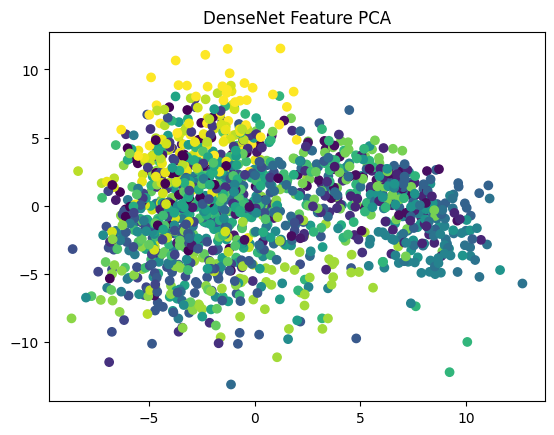

In [27]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(features)

plt.scatter(reduced[:,0],reduced[:,1],c=labels_list)

plt.title("DenseNet Feature PCA")

plt.show()